In [1]:
# can you load the pickle file at the following path: '/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl' ?
import pickle
import random

with open('/Users/stefanovannoni/Desktop/IMPERIAL COLLEGE/Data/data/hcp_ya_dataset/subject_data_1_cleaned_precise_age.pkl', 'rb') as f:
    data = pickle.load(f)

# print random subject 


subject_id = random.choice(list(data.keys()))
print(f"Subject ID: {subject_id}")
print(data[subject_id]['FC'])
print(data[subject_id]['gender'])
print(data[subject_id]['age'])
print(data[subject_id]['FC'].shape)

Subject ID: 729254
[[1.         0.72412302 0.81896327 ... 0.51389247 0.59418012 0.54996367]
 [0.72412302 1.         0.79331191 ... 0.25002481 0.36005349 0.47455108]
 [0.81896327 0.79331191 1.         ... 0.22002814 0.35534968 0.43809214]
 ...
 [0.51389247 0.25002481 0.22002814 ... 1.         0.84451327 0.52411741]
 [0.59418012 0.36005349 0.35534968 ... 0.84451327 1.         0.58782141]
 [0.54996367 0.47455108 0.43809214 ... 0.52411741 0.58782141 1.        ]]
M
25
(379, 379)


/Users/stefanovannoni/.pyenv/versions/imperial/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Label: 6
Image shape: torch.Size([3, 32, 32])


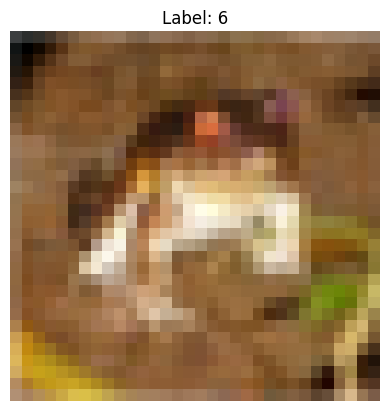

In [2]:
# can you import cifiar10 and load one image using pytorch?
import torch
import torchvision
import torchvision.transforms as transforms

# Define a transform to convert the images to tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load the CIFAR-10 dataset
cifar10_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)   

# Get one image and its label
image, label = cifar10_dataset[0]
print(f"Label: {label}")
print(f"Image shape: {image.shape}")

# can you display the image using matplotlib?
import matplotlib.pyplot as plt
import numpy as np
# Convert the image tensor to a numpy array and transpose it to (H, W, C)
image_np = image.numpy().transpose((1, 2, 0))
# Display the image
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

Number of context panels : 8
Number of answer choices : 8
Correct answer index     : 6
Panel size               : (160, 160)  (W x H)


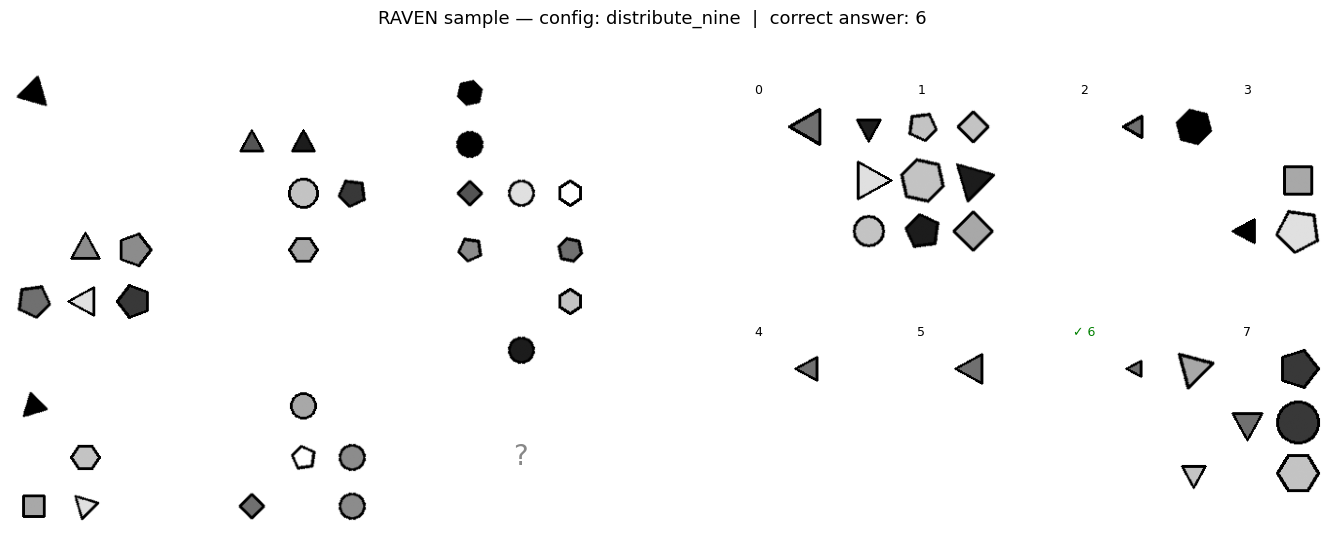

In [3]:

# Load a sample from the RAVEN dataset (HuggingFace)
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ds = load_dataset("HuggingFaceM4/RAVEN", "distribute_nine", split="train")

# Pick the first sample
sample = ds[0]
panels  = sample["panels"]   # 8 context images (the visible 3x3 matrix minus bottom-right)
choices = sample["choices"]  # 8 answer candidates
target  = sample["target"]   # correct answer index (0-7)

print(f"Number of context panels : {len(panels)}")
print(f"Number of answer choices : {len(choices)}")
print(f"Correct answer index     : {target}")
print(f"Panel size               : {panels[0].size}  (W x H)")

# --- plot ---
fig = plt.figure(figsize=(14, 6))
fig.suptitle(f"RAVEN sample — config: distribute_nine  |  correct answer: {target}", fontsize=13)

# Left: 3x3 context grid (panel 8 is the missing piece, shown as a blank)
gs_ctx = gridspec.GridSpec(3, 3, left=0.02, right=0.48, hspace=0.05, wspace=0.05)
for i in range(9):
    ax = fig.add_subplot(gs_ctx[i // 3, i % 3])
    if i < 8:
        ax.imshow(panels[i], cmap="gray", vmin=0, vmax=255)
    else:
        ax.set_facecolor("#dddddd")
        ax.text(0.5, 0.5, "?", ha="center", va="center", fontsize=20, color="#888888",
                transform=ax.transAxes)
    ax.axis("off")

# Right: 8 answer candidates (2 rows x 4 cols), correct one highlighted in green
gs_ans = gridspec.GridSpec(2, 4, left=0.52, right=0.98, hspace=0.1, wspace=0.05)
for i in range(8):
    ax = fig.add_subplot(gs_ans[i // 4, i % 4])
    ax.imshow(choices[i], cmap="gray", vmin=0, vmax=255)
    color = "limegreen" if i == target else "lightgray"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"{'✓ ' if i == target else ''}{i}", fontsize=9,
                 color="green" if i == target else "black")
    ax.axis("off")

plt.show()
